In [2]:
!pip install pandas numpy scikit-learn matplotlib pip install pandas numpy matplotlib scikit-learn

ERROR: Could not find a version that satisfies the requirement install (from versions: none)
ERROR: No matching distribution found for install


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

insurance_data_path = "C:\\Users\\Surface\\Documents\\Regression-Example-master\\insurance.csv"
insurance = pd.read_csv(insurance_data_path)
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.924
1,18.0,male,33.770,1.0,no,Southeast,1725.5523
2,28.0,male,33.000,3.0,no,southeast,$4449.462
3,33.0,male,22.705,0.0,no,northwest,$21984.47061
4,32.0,male,28.880,0.0,no,northwest,$3866.8552


In [5]:
insurance_filled = insurance.copy().dropna()

insurance_filled['region'] = insurance_filled['region'].str.lower()

FEMALE = 'female'
MALE = 'male'
sex_map = {'F': FEMALE, 'woman': FEMALE, 'man': MALE, 'M': MALE}

insurance_filled['sex'] = insurance_filled['sex'].replace(sex_map)

insurance_filled['smoker'] = (insurance_filled['smoker'] == 'yes')

insurance_filled['charges'] = insurance_filled['charges'].str.strip('$').astype('float64')

insurance_pos = insurance_filled.apply(lambda x: x.abs() if np.issubdtype(x.dtype, np.number) else x)

insurance_pos.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,True,southwest,16884.92400
1,18.0,male,33.770,1.0,False,southeast,1725.55230
2,28.0,male,33.000,3.0,False,southeast,4449.46200
3,33.0,male,22.705,0.0,False,northwest,21984.47061
4,32.0,male,28.880,0.0,False,northwest,3866.85520


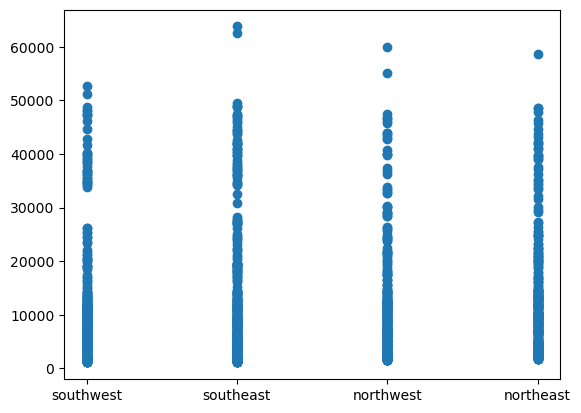

In [6]:
# Task 2: make some linear regression between two columns
df = insurance_pos.copy()
plt.scatter(df['region'], df['charges'])

In [7]:
# Task3 prepare the data for a model fitting
df_new = pd.get_dummies(df, columns=['region'], prefix=['region'])

df_new.drop(columns=['region_southeast'], inplace=True)

df_new['smoker'] = df_new['smoker'].astype('int64')

df_new['is_male'] = (df_new['sex'] == 'male').astype('int64')

df_new.drop(columns=['sex'], inplace=True)

df_new['region_northeast'] = df_new['region_northeast'].astype('int64')
df_new['region_northwest'] = df_new['region_northwest'].astype('int64')
df_new['region_southwest'] = df_new['region_southwest'].astype('int64')

df_new.dropna(inplace=True)

df_new.head()

,age,bmi,children,smoker,charges,region_northeast,region_northwest,region_southwest,is_male
0,19.0,27.900,0.0,1,16884.92400,0,0,1,0
1,18.0,33.770,1.0,0,1725.55230,0,0,0,1
2,28.0,33.000,3.0,0,4449.46200,0,0,0,1
3,33.0,22.705,0.0,0,21984.47061,0,1,0,1
4,32.0,28.880,0.0,0,3866.85520,0,1,0,1


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import r2_score

# Define input and output variables
X = df_new.drop(columns=['charges'])
y = df_new['charges']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the R squared score
r2_score = r2_score(y_test, y_pred)

# Output the mean squared error
r2_score

0.7049323160872817

In [9]:
def preprocess_df(df):
    df_new = pd.get_dummies(df, columns=['region'], prefix=['region'])

    df_new.drop(columns=['region_southeast'], inplace=True)

    df_new['smoker'] = (df_new['smoker'] == 'yes')

    df_new['smoker'] = df_new['smoker'].astype('int64')

    df_new['is_male'] = (df_new['sex'] == 'male').astype('int64')

    df_new.drop(columns=['sex'], inplace=True)

    df_new['region_northeast'] = df_new['region_northeast'].astype('int64')
    df_new['region_northwest'] = df_new['region_northwest'].astype('int64')
    df_new['region_southwest'] = df_new['region_southwest'].astype('int64')

    return df_new

In [10]:
### Task 5: see how the model performs on validation dataset
val_df = pd.read_csv('C:\\Users\\Surface\\Documents\\Regression-Example-master\\validation_dataset.csv')
input_df = preprocess_df(val_df)

predictions = model.predict(input_df)

validation_data = val_df.copy()

validation_data['predicted_charges'] = predictions

validation_data.loc[validation_data['predicted_charges'] < 1000, 'predicted_charges'] = 1000

validation_data.head()

,age,sex,bmi,children,smoker,region,predicted_charges
0,18.0,female,24.090000,1.0,no,southeast,1000.000000
1,39.0,male,26.410000,0.0,yes,northeast,30956.214707
2,27.0,male,29.150000,0.0,yes,southeast,27799.409607
3,71.0,male,65.502135,13.0,yes,southeast,57194.414804
4,28.0,male,38.060000,0.0,no,southeast,6685.426312
